# Feature Transformation

### We are learning how to encode/fill missing values etc, and today we will learn how to do something called mathematical transformation.

### We will learn Log Transform, Reciprocal Transform and Power Transform today

### What happens after transformation? -> After applying, the pdf will convert into a normal distribution

# Function Transformer

#### When to use log transform? 
* Cannot use it for -ve values
* For right-skewed data we must use log transform -> it will center the data

#### When to use reciprocal transform? (1/x)
* Small values become big, and vice-versa
* You can get normally distribubted sometimes using this approach

#### When to use sq transform? (x^2)
* For left-skewed data we must use sqare transform

In [33]:
import numpy as np
import pandas as pd

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [34]:
df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])

In [35]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [36]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

/var/folders/lb/grt31mld6cz3cxzp2f269n_w0000gp/T/ipykernel_67375/1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [37]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [38]:
X = df.iloc[:, 1:3]
y = df.iloc[:,0]

In [39]:
# Train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

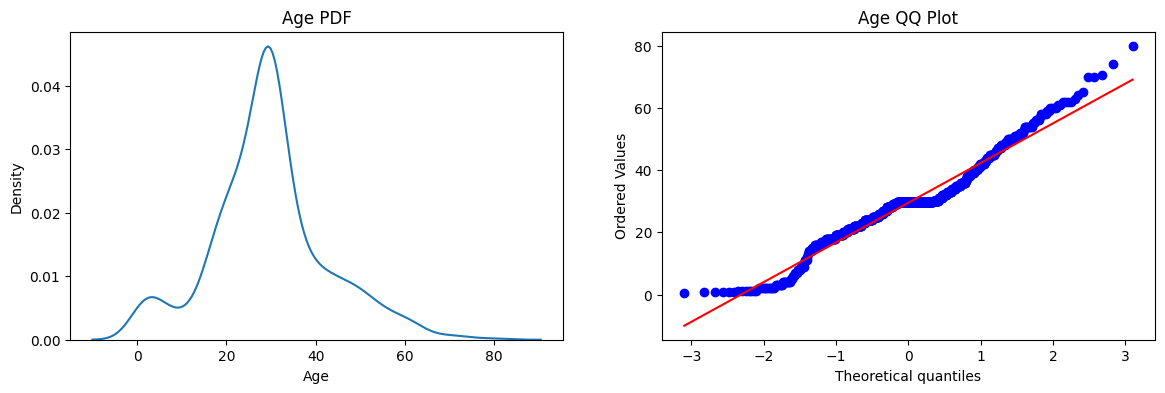

In [40]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()



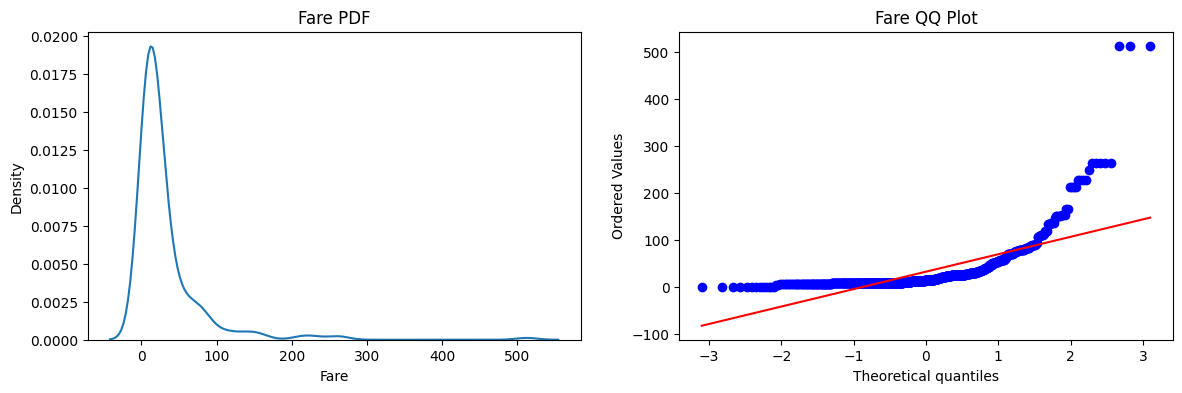

In [41]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()



In [42]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [47]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("accuracy LR: ", accuracy_score(y_test, y_pred))
print("accuracy DT: ", accuracy_score(y_test, y_pred1))

accuracy LR:  0.6480446927374302
accuracy DT:  0.6871508379888268


In [48]:
trf = FunctionTransformer(func=np.log1p)

In [51]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [52]:
clf3 = LogisticRegression()
clf4 = DecisionTreeClassifier()

clf3.fit(X_train_transformed, y_train)
clf4.fit(X_train_transformed, y_train)

y_pred = clf3.predict(X_test_transformed)
y_pred1 = clf4.predict(X_test_transformed)

print("accuracy LR: ", accuracy_score(y_test, y_pred))
print("accuracy DT: ", accuracy_score(y_test, y_pred1))

accuracy LR:  0.6815642458100558
accuracy DT:  0.6871508379888268
